In [7]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded")

Libraries loaded


In [8]:
# Cell 2: Load Data
print("\n" + "="*60)
print("LOADING DATA")
print("="*60)

gen1 = pd.read_csv('../data/raw/Plant_1_Generation_Data.csv')
weather1 = pd.read_csv('../data/raw/Plant_1_Weather_Sensor_Data.csv')
gen2 = pd.read_csv('../data/raw/Plant_2_Generation_Data.csv')
weather2 = pd.read_csv('../data/raw/Plant_2_Weather_Sensor_Data.csv')

print(f"Plant 1 Generation: {gen1.shape}")
print(f"Plant 1 Weather:    {weather1.shape}")
print(f"Plant 2 Generation: {gen2.shape}")
print(f"Plant 2 Weather:    {weather2.shape}")



LOADING DATA
Plant 1 Generation: (68778, 7)
Plant 1 Weather:    (3182, 6)
Plant 2 Generation: (67698, 7)
Plant 2 Weather:    (3259, 6)


In [9]:
# Cell 3: Fix Date Format Inconsistency
print("\n" + "="*60)
print("STANDARDIZING DATE FORMATS")
print("="*60)

# Check current formats
print("Before standardization:")
print(f"gen1 DATE_TIME sample: {gen1['DATE_TIME'].iloc[0]}")
print(f"weather1 DATE_TIME sample: {weather1['DATE_TIME'].iloc[0]}")
print(f"gen2 DATE_TIME sample: {gen2['DATE_TIME'].iloc[0]}")
print(f"weather2 DATE_TIME sample: {weather2['DATE_TIME'].iloc[0]}")

# Convert all to standard datetime format
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'], dayfirst=True)
weather1['DATE_TIME'] = pd.to_datetime(weather1['DATE_TIME'])
gen2['DATE_TIME'] = pd.to_datetime(gen2['DATE_TIME'])
weather2['DATE_TIME'] = pd.to_datetime(weather2['DATE_TIME'])

# Convert back to string with consistent format
gen1['DATE_TIME'] = gen1['DATE_TIME'].dt.strftime('%Y-%m-%d %H:%M:%S')
weather1['DATE_TIME'] = weather1['DATE_TIME'].dt.strftime('%Y-%m-%d %H:%M:%S')
gen2['DATE_TIME'] = gen2['DATE_TIME'].dt.strftime('%Y-%m-%d %H:%M:%S')
weather2['DATE_TIME'] = weather2['DATE_TIME'].dt.strftime('%Y-%m-%d %H:%M:%S')

print("\nAfter standardization:")
print(f"gen1 DATE_TIME sample: {gen1['DATE_TIME'].iloc[0]}")
print(f"weather1 DATE_TIME sample: {weather1['DATE_TIME'].iloc[0]}")

print("All dates standardized to YYYY-MM-DD HH:MM:SS format")


STANDARDIZING DATE FORMATS
Before standardization:
gen1 DATE_TIME sample: 15-05-2020 00:00
weather1 DATE_TIME sample: 2020-05-15 00:00:00
gen2 DATE_TIME sample: 2020-05-15 00:00:00
weather2 DATE_TIME sample: 2020-05-15 00:00:00

After standardization:
gen1 DATE_TIME sample: 2020-05-15 00:00:00
weather1 DATE_TIME sample: 2020-05-15 00:00:00
All dates standardized to YYYY-MM-DD HH:MM:SS format


In [10]:
# Cell 4: Basic Info
print("\n" + "="*60)
print("DATA OVERVIEW")
print("="*60)

print("\nGeneration Data Columns:")
print(gen1.columns.tolist())

print("\nWeather Data Columns:")
print(weather1.columns.tolist())

print("\nFirst few rows (Plant 1 Generation):")
print(gen1.head())

print("\nBasic statistics (Plant 1 Generation):")
print(gen1.describe())



DATA OVERVIEW

Generation Data Columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']

Weather Data Columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

First few rows (Plant 1 Generation):
             DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  2020-05-15 00:00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  2020-05-15 00:00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  2020-05-15 00:00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  2020-05-15 00:00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  2020-05-15 00:00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  

Basic statistics (Plant 1 Generation):
        PLANT_ID      DC_POWER      AC_POWER 

In [11]:
# Cell 5: Check Missing Values
print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)

print(f"Plant 1 Generation: {gen1.isnull().sum().sum()} missing")
print(f"Plant 1 Weather:    {weather1.isnull().sum().sum()} missing")
print(f"Plant 2 Generation: {gen2.isnull().sum().sum()} missing")
print(f"Plant 2 Weather:    {weather2.isnull().sum().sum()} missing")


MISSING VALUES CHECK
Plant 1 Generation: 0 missing
Plant 1 Weather:    0 missing
Plant 2 Generation: 0 missing
Plant 2 Weather:    0 missing


In [12]:
# Cell 6: Merge Plant 1 Data
df1 = gen1.merge(weather1, on=['DATE_TIME', 'PLANT_ID'])
df1['timestamp'] = pd.to_datetime(df1['DATE_TIME'])

print("\n" + "="*60)
print("MERGED DATA (Plant 1)")
print("="*60)
print(f"Shape: {df1.shape}")
print(f"Date range: {df1['timestamp'].min()} to {df1['timestamp'].max()}")
print(f"Duration: {(df1['timestamp'].max() - df1['timestamp'].min()).days} days")


MERGED DATA (Plant 1)
Shape: (68774, 12)
Date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Duration: 33 days


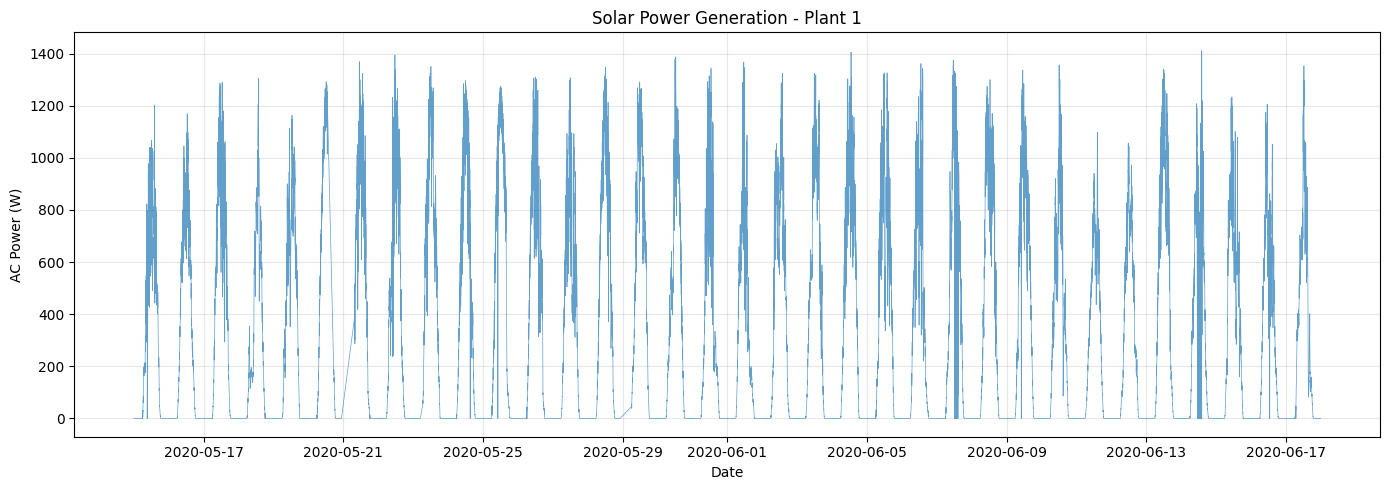

In [13]:
# Cell 7: Visualize Power Over Time
plt.figure(figsize=(14, 5))
plt.plot(df1['timestamp'], df1['AC_POWER'], linewidth=0.5, alpha=0.7)
plt.xlabel('Date')
plt.ylabel('AC Power (W)')
plt.title('Solar Power Generation - Plant 1')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

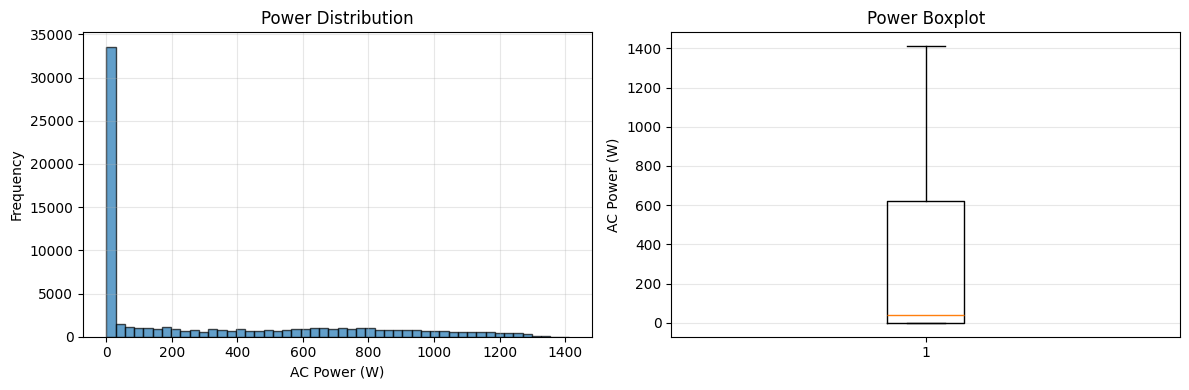

In [14]:
# Cell 8: Power Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df1['AC_POWER'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('AC Power (W)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Power Distribution')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df1['AC_POWER'])
axes[1].set_ylabel('AC Power (W)')
axes[1].set_title('Power Boxplot')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

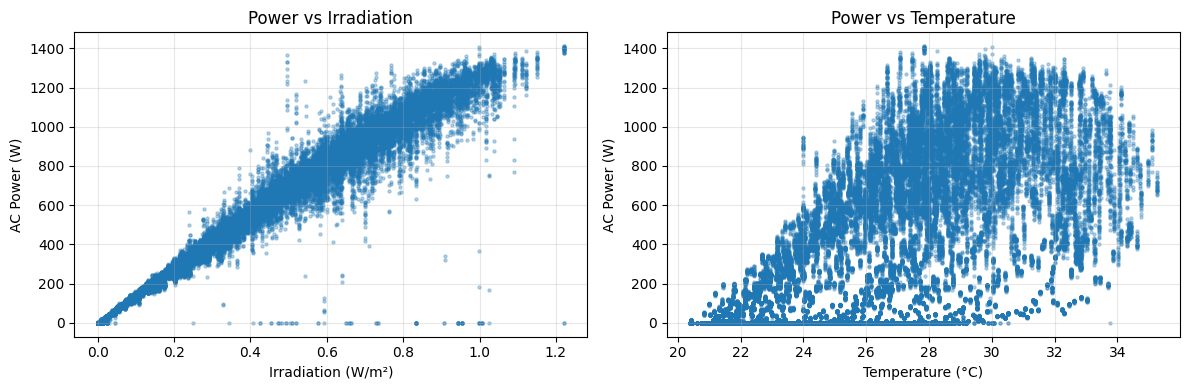

In [15]:
# Cell 9: Key Relationships
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Power vs Irradiation
axes[0].scatter(df1['IRRADIATION'], df1['AC_POWER'], alpha=0.3, s=5)
axes[0].set_xlabel('Irradiation (W/m²)')
axes[0].set_ylabel('AC Power (W)')
axes[0].set_title('Power vs Irradiation')
axes[0].grid(True, alpha=0.3)

# Power vs Temperature
axes[1].scatter(df1['AMBIENT_TEMPERATURE'], df1['AC_POWER'], alpha=0.3, s=5)
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('AC Power (W)')
axes[1].set_title('Power vs Temperature')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

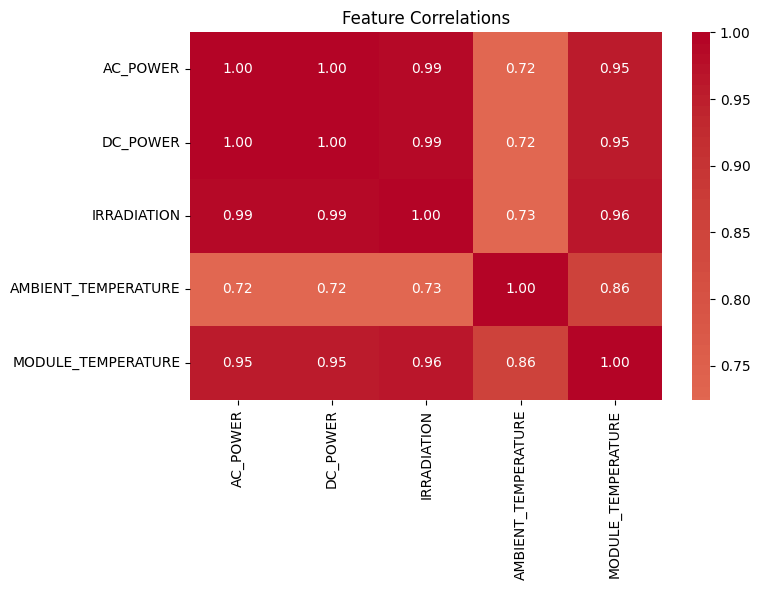


Correlations with AC_POWER:
AC_POWER               1.000000
DC_POWER               0.999996
IRRADIATION            0.989340
MODULE_TEMPERATURE     0.954924
AMBIENT_TEMPERATURE    0.724903
Name: AC_POWER, dtype: float64


In [16]:
# Cell 10: Correlation Matrix
numeric_cols = ['AC_POWER', 'DC_POWER', 'IRRADIATION', 
                'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']
corr = df1[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlations')
plt.tight_layout()
plt.show()

print("\nCorrelations with AC_POWER:")
print(corr['AC_POWER'].sort_values(ascending=False))